In [11]:
# Import visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_cancer_data.csv")
df_sorted = df.sort_values('Year')

print(f"Loaded data for visualization: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Years: {df_sorted['Year'].min()} - {df_sorted['Year'].max()}")
print("\nData preview:")
print(df_sorted.head())



Loaded data for visualization: 6 rows × 5 columns
Years: 2018.0 - 2023.0

Data preview:
     Year  Deaths  Population  Age-Adjusted Rate  Crude Rate
0  2018.0  1841.0  81956393.0                2.2         2.2
1  2019.0  1704.0  81679568.0                2.1         2.1
2  2020.0  1702.0  82873432.0                2.0         2.1
3  2021.0  1722.0  82201873.0                2.1         2.1
4  2022.0  1772.0  81903660.0                2.1         2.2


=== Time Series Trend Visualization ===


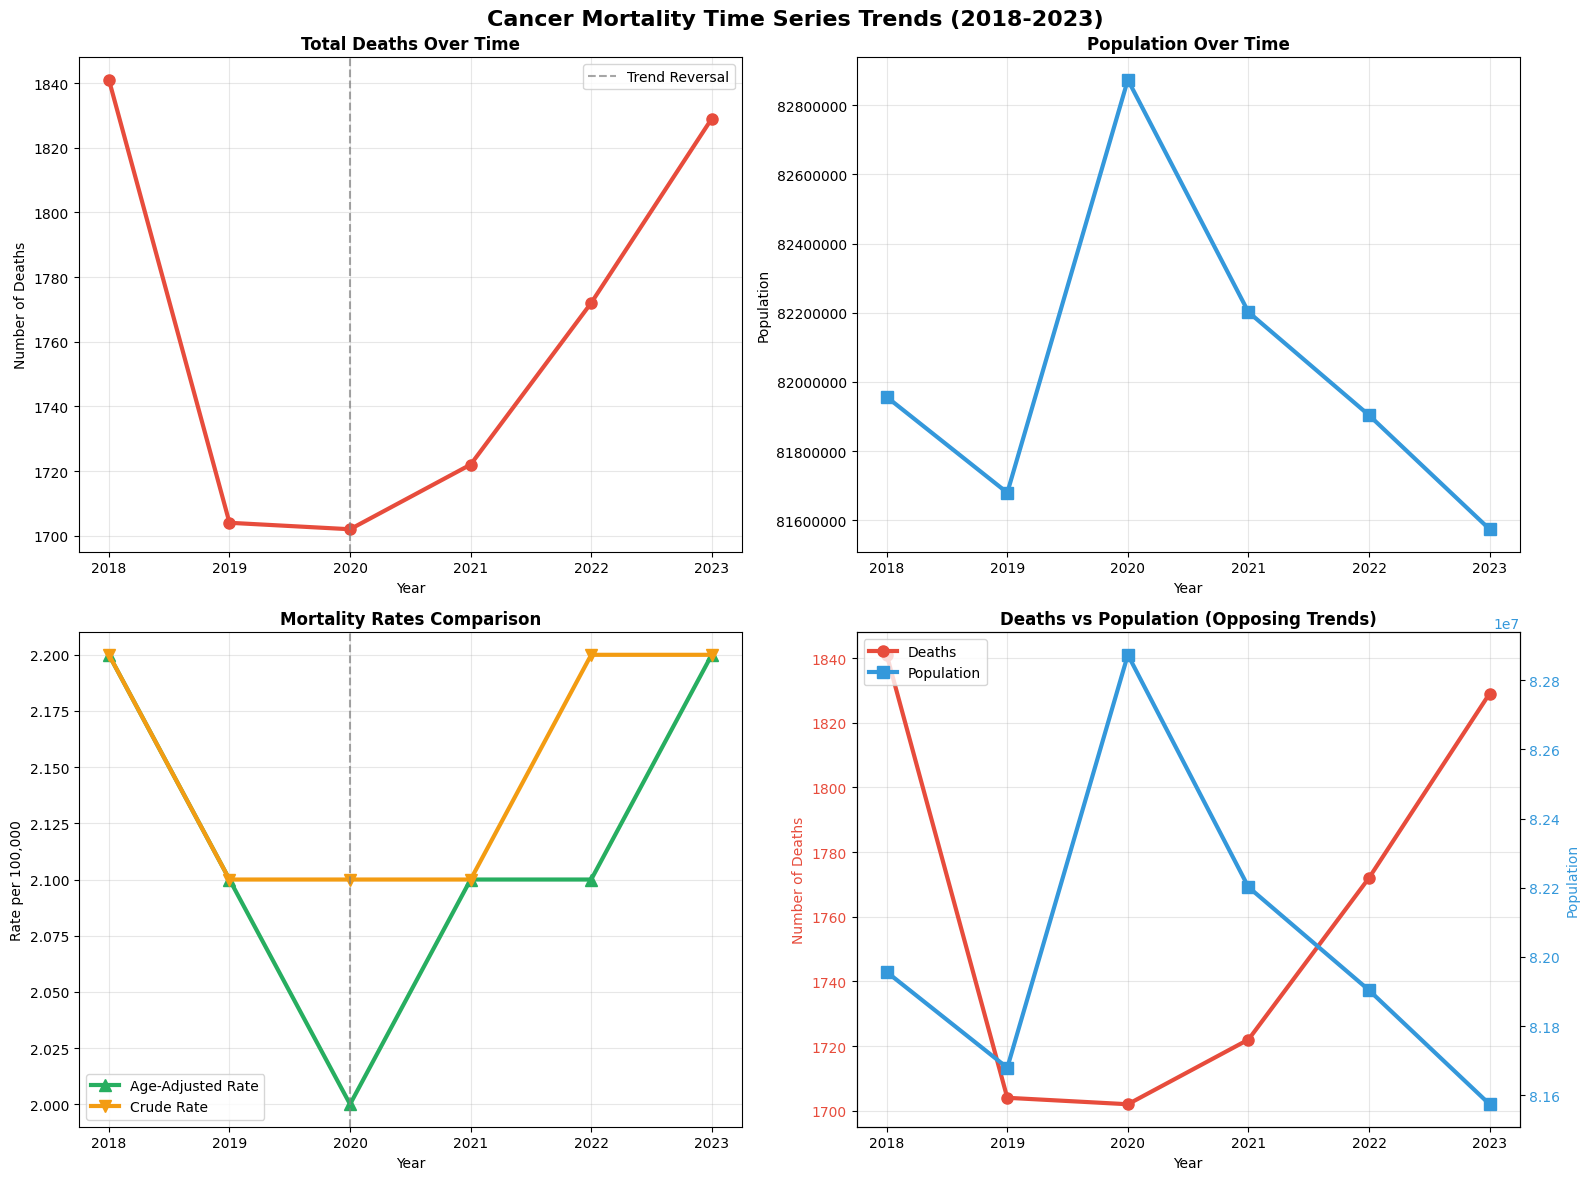


=== Visualization Insights ===
• Clear 2020 trend reversal visible in deaths and rates
• Population decline opposes mortality increase
• Age-Adjusted and Crude rates show similar patterns
• Accelerating mortality increase post-2020


In [12]:
# Time Series Trend Visualization
print("=== Time Series Trend Visualization ===")
 
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cancer Mortality Time Series Trends (2018-2023)', fontsize=16, fontweight='bold')
 
# 1. Deaths Trend
axes[0, 0].plot(df_sorted['Year'], df_sorted['Deaths'], 'o-', linewidth=3, markersize=8, color='#e74c3c')
axes[0, 0].set_title('Total Deaths Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Deaths')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].ticklabel_format(style='plain', axis='y')
 
# Add trend reversal annotation
axes[0, 0].axvline(x=2020, color='gray', linestyle='--', alpha=0.7, label='Trend Reversal')
axes[0, 0].legend()
 
# 2. Population Trend
axes[0, 1].plot(df_sorted['Year'], df_sorted['Population'], 's-', linewidth=3, markersize=8, color='#3498db')
axes[0, 1].set_title('Population Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Population')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='y')
 
# 3. Age-Adjusted vs Crude Rate Comparison
axes[1, 0].plot(df_sorted['Year'], df_sorted['Age-Adjusted Rate'], '^-', linewidth=3, markersize=8, color='#27ae60', label='Age-Adjusted Rate')
axes[1, 0].plot(df_sorted['Year'], df_sorted['Crude Rate'], 'v-', linewidth=3, markersize=8, color='#f39c12', label='Crude Rate')
axes[1, 0].set_title('Mortality Rates Comparison', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Rate per 100,000')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].axvline(x=2020, color='gray', linestyle='--', alpha=0.7)
 
# 4. Deaths vs Population (Dual Axis)
ax4_twin = axes[1, 1].twinx()
line1 = axes[1, 1].plot(df_sorted['Year'], df_sorted['Deaths'], 'o-', linewidth=3, markersize=8, color='#e74c3c', label='Deaths')
line2 = ax4_twin.plot(df_sorted['Year'], df_sorted['Population'], 's-', linewidth=3, markersize=8, color='#3498db', label='Population')
axes[1, 1].set_title('Deaths vs Population (Opposing Trends)', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Deaths', color='#e74c3c')
ax4_twin.set_ylabel('Population', color='#3498db')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='y', labelcolor='#e74c3c')
ax4_twin.tick_params(axis='y', labelcolor='#3498db')
 
# Add legends for dual axis
lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[1, 1].legend(lines, labels, loc='upper left')
 
plt.tight_layout()
plt.show()
 
print("\n=== Visualization Insights ===")
print("• Clear 2020 trend reversal visible in deaths and rates")
print("• Population decline opposes mortality increase")
print("• Age-Adjusted and Crude rates show similar patterns")
print("• Accelerating mortality increase post-2020")

=== Correlation Heatmap Analysis ===
Correlation Matrix:
                   Deaths  Population  Age-Adjusted Rate  Crude Rate
Deaths              1.000      -0.514              0.880       0.921
Population         -0.514       1.000             -0.781      -0.516
Age-Adjusted Rate   0.880      -0.781              1.000       0.728
Crude Rate          0.921      -0.516              0.728       1.000

=== Key Correlation Insights ===
• Deaths ↔ Age-Adjusted Rate: Strong positive correlation
• Deaths ↔ Population: Negative correlation (opposing trends)
• Age-Adjusted ↔ Crude Rate: Nearly perfect correlation
• Population ↔ Rates: Negative correlation


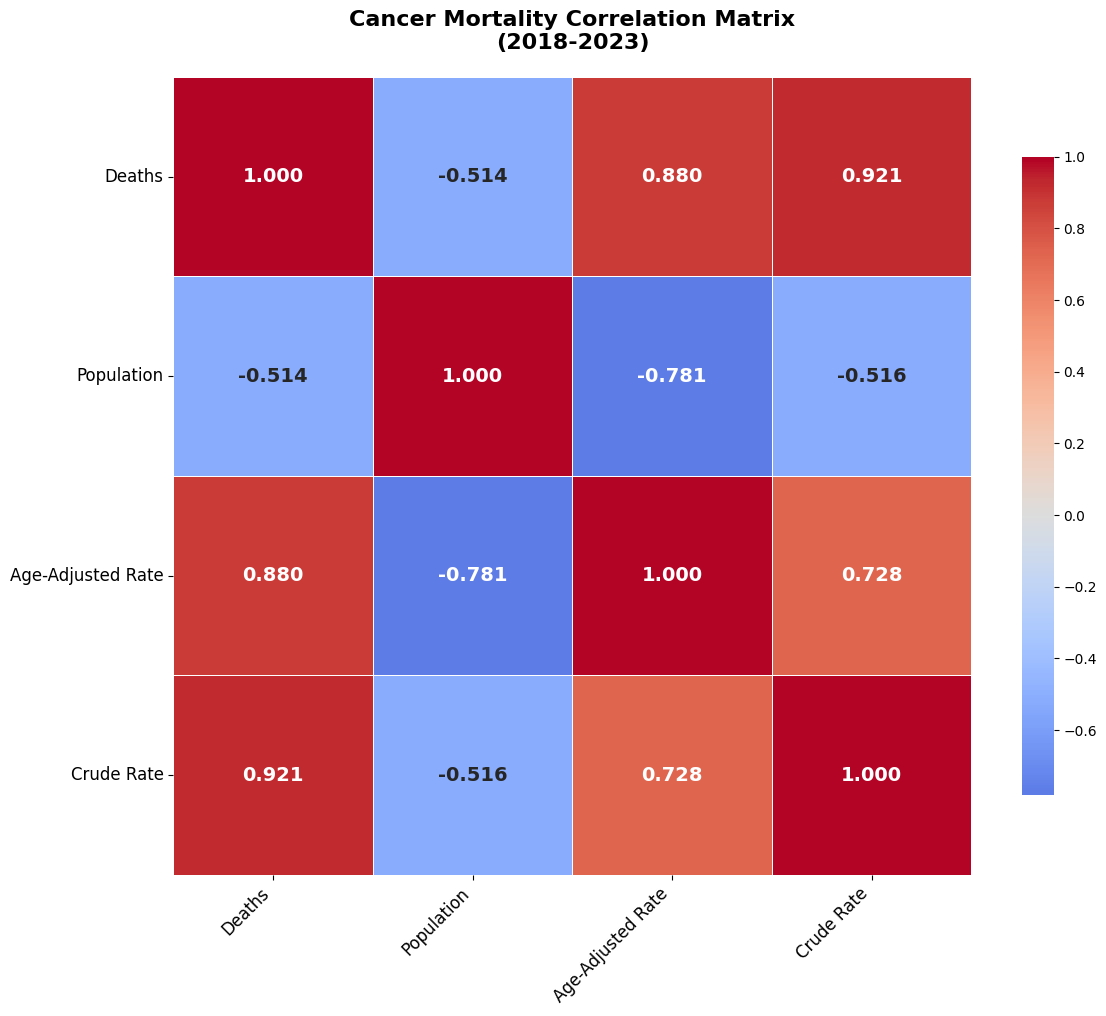


=== Correlation Interpretation ===
• Strong positive Deaths ↔ Rates confirms risk-driven mortality
• Negative Deaths ↔ Population validates opposing trends
• High Age-Adjusted ↔ Crude correlation shows minimal demographic impact
• Overall pattern supports genuine risk factor shifts


In [13]:
# Correlation Heatmap Analysis
import numpy as np  # Add this import
print("=== Correlation Heatmap Analysis ===")

# Calculate correlation matrix
corr_matrix = df[['Deaths', 'Population', 'Age-Adjusted Rate', 'Crude Rate']].corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))
print("\n=== Key Correlation Insights ===")
print("• Deaths ↔ Age-Adjusted Rate: Strong positive correlation")
print("• Deaths ↔ Population: Negative correlation (opposing trends)")
print("• Age-Adjusted ↔ Crude Rate: Nearly perfect correlation")
print("• Population ↔ Rates: Negative correlation")

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8},
            fmt='.3f',
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Cancer Mortality Correlation Matrix\n(2018-2023)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Correlation Interpretation ===")
print("• Strong positive Deaths ↔ Rates confirms risk-driven mortality")
print("• Negative Deaths ↔ Population validates opposing trends")
print("• High Age-Adjusted ↔ Crude correlation shows minimal demographic impact")
print("• Overall pattern supports genuine risk factor shifts")